In [1]:
import numpy as np
import pandas as pd
import os
from PIL import Image
import skimage
from matplotlib import pyplot as plt
from tqdm import tqdm
import cv2
import torch
import pickle
import glob
from skimage.color import label2rgb

import warnings
warnings.filterwarnings('ignore', message='overflow encountered in exp')

In [2]:
# from https://github.com/MouseLand/cellpose/blob/main/notebooks/test_Cellpose-SAM.ipynb

from cellpose import models, core, io, plot, transforms
from pathlib import Path
from tqdm import trange

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.11.7 
torch version:  	2.3.1+cu121! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 


2026-04-29 00:53:27,244 [INFO] WRITING LOG OUTPUT TO /global/homes/k/kerrilu/.cellpose/run.log
2026-04-29 00:53:27,246 [INFO] 
cellpose version: 	4.0.6 
platform:       	linux 
python version: 	3.11.7 
torch version:  	2.3.1+cu121
2026-04-29 00:53:27,612 [INFO] ** TORCH CUDA version installed and working. **
2026-04-29 00:53:27,616 [INFO] ** TORCH CUDA version installed and working. **
2026-04-29 00:53:27,620 [INFO] >>>> using GPU (CUDA)
2026-04-29 00:53:29,330 [INFO] >>>> loading model /global/homes/k/kerrilu/.cellpose/models/cpsam


In [3]:
def detect_cells(img, T):
    masks, flows, styles = model.eval(img, cellprob_threshold=T)
    return masks, flows, styles

In [4]:
# https://stackoverflow.com/questions/66595055/fastest-way-of-computing-binary-mask-iou-with-numpy
def iou(mask1, mask2):
    intersection = (mask1 * mask2).sum()
    if intersection == 0:
        return 0.0
    union = torch.logical_or(mask1, mask2).to(torch.int).sum()
    return intersection / union

import itertools
def compute_pair_to_iou_dict(masks):
    indices = np.arange(len(masks))
    pairs = itertools.combinations(indices, 2)
    pair_to_iou = {}
    for pair in pairs:
        i, j = pair
        if masks[i].sum()==0 or masks[j].sum()==0:
            pair_to_iou[tuple(pair)] = 0
        else:
            pair_to_iou[tuple(pair)] = iou(masks[i], masks[j]).numpy()
    return pair_to_iou

In [5]:
T_values = np.arange(-5, 5.01, 1)

# Finite sample algorithm

In [6]:
IOU_threshold = 0.75
alpha = .2

In [7]:
file = open('../data/cell_seg/conformal_ious_cellpose_SAM.pkl', 'rb')
results_table = pickle.load(file)
file.close()

file = open('../data/cell_seg/conformal_ious_calibration_cellpose_SAM_remove_duplicate_masks.pkl', 'rb')
results_table_calibration = pickle.load(file)
file.close()

results_table = pd.merge(results_table, results_table_calibration[['image_number', 'coord']])

In [8]:
m = int(len(results_table)/2)
results_table['calibration_step'] = 'step2'
results_table.loc[results_table.sample(n=m, random_state=0).index, 'calibration_step'] = 'step1'

In [9]:
results_table_1 = results_table[results_table['calibration_step'] == 'step1']
results_table_2 = results_table[results_table['calibration_step'] == 'step2']

In [10]:
print(len(results_table_1))
print(len(results_table_2))

462
463


Step 1

In [11]:
import itertools
import math

T_ordering_indices = []
IOUs = np.array([np.array(x) for x in results_table_1["IOUs"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)
while True:
    coverage_by_T = IOUs_high.sum(axis=0)
    if np.max(coverage_by_T) == 0:
        break
    else:
        best_T = np.argmax(coverage_by_T)
        calibration_pixels_covered = np.argwhere(IOUs_high[:, best_T]==1)
        IOUs_high = np.delete(IOUs_high, calibration_pixels_covered, axis=0)
        T_ordering_indices.append(int(best_T))

T_ordering = T_values[T_ordering_indices]
print("T indices in ranked order from highest to lowest priority:", T_ordering_indices)
print("T in ranked order from highest to lowest priority:", T_ordering)

T indices in ranked order from highest to lowest priority: [5, 3, 7, 0, 4]
T in ranked order from highest to lowest priority: [ 0. -2.  2. -5. -1.]


Step 2

In [12]:
pair_to_iou_dicts = []
classified_as_cell = []
for index, row in tqdm(results_table_2.iterrows(), total=results_table_2.shape[0]):
    image_number = row["image_number"]
    coord = row["coord"]
    pred_shapes_coord = []
    classified_as_cell_coord = []
    
    img = io.imread('../'+image_number)[...,1]
    
    for T in T_ordering[:5]:
        pred_segmentation, _, _ = detect_cells(img, T)
        if pred_segmentation[coord] == 0:
            pred_shape = np.zeros(img.shape)
            classified_as_cell_coord.append(False)
        else:
            pred_shape = pred_segmentation==pred_segmentation[coord]
            classified_as_cell_coord.append(True)
        pred_shapes_coord.append(torch.from_numpy(pred_shape))
        
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))
    classified_as_cell.append(classified_as_cell_coord)

results_table_2["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
results_table_2["Classified as Cell"] = classified_as_cell

100%|██████████| 463/463 [08:27<00:00,  1.10s/it]
/tmp/ipykernel_2251577/941921223.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_2["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
/tmp/ipykernel_2251577/941921223.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_2["Classified as Cell"] = classified_as_cell


In [13]:
def remove_duplicate_masks_finite_sample(indices, pair_to_iou, iou_threshold):
    if len(indices) == 1:
        return indices
    else:
        indices_to_keep = remove_duplicate_masks_finite_sample(indices[:-1], pair_to_iou, iou_threshold)
        for index in indices[:-1]:
            IOU = pair_to_iou[(index, indices[-1])]
            if IOU > iou_threshold:
                return indices_to_keep
        indices_to_keep.append(indices[-1])
        return indices_to_keep

In [14]:
IOU_threshold_duplicate_mask = 0.9
n2 = len(results_table_2)
pair_to_iou_dicts = np.array(results_table_2["Pred Mask Pair to IOUs"])
IOUs = np.array([np.array(x) for x in results_table_2["IOUs"]])
IOUs_high = (IOUs>IOU_threshold).astype(int)[:, T_ordering_indices]
target_risk = alpha - (1-alpha)/n2

for i in range(len(T_ordering_indices)):
    num_points_covered = 0
    for j in range(n2):
        pair_to_iou = pair_to_iou_dicts[j]
        indices_to_keep = remove_duplicate_masks_finite_sample(list(np.arange(i+1)), pair_to_iou, IOU_threshold_duplicate_mask)
        if np.max(IOUs_high[j][indices_to_keep]) == 1:
            num_points_covered += 1
    risk = 1 - num_points_covered / n2 # fraction of points that have not been covered
    if risk <= target_risk:
        break

T_confidence_set_indices = T_ordering_indices[:i+1]
T_confidence_set = T_values[T_confidence_set_indices]

print("target risk:", target_risk)
print("final risk:", risk)
if risk > target_risk:
    print("alpha too small")
else:
    print("T confidence set indices:", T_confidence_set_indices)
    print("T confidence set:", T_confidence_set)

target risk: 0.19827213822894169
final risk: 0.19654427645788342
T confidence set indices: [5]
T confidence set: [0.]


In [15]:
file = open('cell_segmentation_finite_sample_calibration_step_2.pkl', 'wb')
pickle.dump(results_table_2, file)
file.close()

In [16]:
results_table_2

,image_number,coord,IOUs,calibration_step,Pred Mask Pair to IOUs,Classified as Cell
0,data/cell_seg/cellpose_test_greyscale/044_img.png,"(172, 53)","[0.7663934230804443, 0.77379310131073, 0.78902...",step2,"{(0, 1): 0.96062994, (0, 2): 0.94426227, (0, 3...","[True, True, True, True, True]"
3,data/cell_seg/cellpose_test_greyscale/044_img.png,"(67, 105)","[0.44285714626312256, 0.44285714626312256, 0.4...",step2,"{(0, 1): 1.0, (0, 2): 0.8606557, (0, 3): 1.0, ...","[True, True, True, True, True]"
4,data/cell_seg/cellpose_test_greyscale/044_img.png,"(103, 42)","[0.8606557250022888, 0.8606557250022888, 0.860...",step2,"{(0, 1): 1.0, (0, 2): 0.99568343, (0, 3): 1.0,...","[True, True, True, True, True]"
7,data/cell_seg/cellpose_test_greyscale/044_img.png,"(87, 119)","[0.8945736289024353, 0.8945736289024353, 0.894...",step2,"{(0, 1): 1.0, (0, 2): 0.9856, (0, 3): 1.0, (0,...","[True, True, True, True, True]"
9,data/cell_seg/cellpose_test_greyscale/044_img.png,"(88, 91)","[0.7150943279266357, 0.7150943279266357, 0.715...",step2,"{(0, 1): 1.0, (0, 2): 0.93318963, (0, 3): 1.0,...","[True, True, True, True, True]"
...,...,...,...,...,...,...
908,data/cell_seg/cellpose_test_greyscale/061_img.png,"(294, 165)","[0.7951706647872925, 0.7951706647872925, 0.795...",step2,"{(0, 1): 1.0, (0, 2): 0.94959766, (0, 3): 1.0,...","[True, True, True, True, True]"
912,data/cell_seg/cellpose_test_greyscale/061_img.png,"(44, 78)","[0.6541250944137573, 0.6541250944137573, 0.654...",step2,"{(0, 1): 0.94373286, (0, 2): 0.72564226, (0, 3...","[True, True, True, True, True]"
919,data/cell_seg/cellpose_test_greyscale/061_img.png,"(255, 396)","[0.788543164730072, 0.788543164730072, 0.79871...",step2,"{(0, 1): 0.90125275, (0, 2): 0.886345, (0, 3):...","[True, True, True, True, True]"
920,data/cell_seg/cellpose_test_greyscale/061_img.png,"(324, 256)","[0.8874552249908447, 0.8874552249908447, 0.906...",step2,"{(0, 1): 0.9720121, (0, 2): 0.91135305, (0, 3)...","[True, True, True, True, True]"


# Find coverage on test set

In [17]:
file = open('../data/cell_seg/conformal_ious_test_cellpose_SAM_remove_duplicate_masks.pkl', 'rb')
results_table_test_asymptotic = pickle.load(file)
file.close()

In [18]:
results_table_test = results_table_test_asymptotic[['image_number', 'coord']]

In [19]:
IOUs = []
pair_to_iou_dicts = []
classified_as_cell = []
for index, row in tqdm(results_table_test.iterrows(), total=results_table_test.shape[0]):
    image_number = row["image_number"]
    coord = row["coord"]
    pred_shapes_coord = []
    classified_as_cell_coord = []
    IOUs_coord = []
    
    img = io.imread('../'+image_number)[...,1]
    true_segmentation = io.imread('../'+image_number[:-7]+'masks.png')
    true_shape = true_segmentation==true_segmentation[coord]
    
    for T in T_confidence_set:
        pred_segmentation, _, _ = detect_cells(img, T)
        if pred_segmentation[coord] == 0:
            IOU = 0 # the pixel is predicted to be a non-cell
            pred_shape = np.zeros(img.shape)
            classified_as_cell_coord.append(False)
        else:
            pred_shape = pred_segmentation==pred_segmentation[coord]
            IOU = iou(torch.from_numpy(true_shape), torch.from_numpy(pred_shape)).numpy().item()
            classified_as_cell_coord.append(True)
        pred_shapes_coord.append(torch.from_numpy(pred_shape))
        IOUs_coord.append(IOU)
        
    pair_to_iou_dicts.append(compute_pair_to_iou_dict(pred_shapes_coord))
    classified_as_cell.append(classified_as_cell_coord)
    IOUs.append(IOUs_coord)

results_table_test["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
results_table_test["Classified as Cell"] = classified_as_cell
results_table_test["IOUs"] = IOUs

100%|██████████| 659/659 [02:31<00:00,  4.35it/s]
/tmp/ipykernel_2251577/2404565154.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_test["Pred Mask Pair to IOUs"] = pair_to_iou_dicts
/tmp/ipykernel_2251577/2404565154.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_test["Classified as Cell"] = classified_as_cell
/tmp/ipykernel_2251577/2404565154.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

In [20]:
results_table_test["Indices Classified as Cell"] = results_table_test["Classified as Cell"].apply(lambda x: np.argwhere(x)[:, 0])

results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_finite_sample(list(np.arange(len(T_confidence_set))), x, iou_threshold=IOU_threshold_duplicate_mask))
results_table_test["Final Mask Indices"] = results_table_test.apply(lambda x: np.intersect1d(x["Final Mask Indices"], x["Indices Classified as Cell"]), axis=1)

results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))
results_table_test["Final Mask IOUs"] = results_table_test.apply(lambda x: np.array(x["IOUs"])[x["Final Mask Indices"]], axis=1)
results_table_test["Final Mask max IOU"] = results_table_test["Final Mask IOUs"].map(lambda x: 0 if len(x)==0 else np.max(x))

/tmp/ipykernel_2251577/1090305509.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_test["Indices Classified as Cell"] = results_table_test["Classified as Cell"].apply(lambda x: np.argwhere(x)[:, 0])
/tmp/ipykernel_2251577/1090305509.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_finite_sample(list(np.arange(len(T_confidence_set))), x, iou_threshold=IOU_threshol

In [21]:
results_table_test

,image_number,coord,Pred Mask Pair to IOUs,Classified as Cell,IOUs,Indices Classified as Cell,Final Mask Indices,Final Mask Number,Final Mask IOUs,Final Mask max IOU
0,data/cell_seg/cellpose_test_greyscale/024_img.png,"(211, 151)",{},[True],[0.75],[0],[0],1,[0.75],0.750000
1,data/cell_seg/cellpose_test_greyscale/024_img.png,"(292, 183)",{},[True],[0.7507886290550232],[0],[0],1,[0.7507886290550232],0.750789
2,data/cell_seg/cellpose_test_greyscale/024_img.png,"(87, 28)",{},[True],[0.6713286638259888],[0],[0],1,[0.6713286638259888],0.671329
3,data/cell_seg/cellpose_test_greyscale/024_img.png,"(88, 128)",{},[True],[0.6805555820465088],[0],[0],1,[0.6805555820465088],0.680556
4,data/cell_seg/cellpose_test_greyscale/024_img.png,"(404, 321)",{},[True],[0.8377518653869629],[0],[0],1,[0.8377518653869629],0.837752
...,...,...,...,...,...,...,...,...,...,...
654,data/cell_seg/cellpose_test_greyscale/060_img.png,"(485, 139)",{},[True],[0.9600874781608582],[0],[0],1,[0.9600874781608582],0.960087
655,data/cell_seg/cellpose_test_greyscale/060_img.png,"(267, 158)",{},[True],[0.909621000289917],[0],[0],1,[0.909621000289917],0.909621
656,data/cell_seg/cellpose_test_greyscale/060_img.png,"(337, 327)",{},[True],[0.9848024249076843],[0],[0],1,[0.9848024249076843],0.984802
657,data/cell_seg/cellpose_test_greyscale/060_img.png,"(311, 58)",{},[True],[0.9673638343811035],[0],[0],1,[0.9673638343811035],0.967364


In [22]:
results_table_test_high_IOUs = results_table_test[results_table_test["Final Mask max IOU"] > IOU_threshold]
coverage = len(results_table_test_high_IOUs) / len(results_table_test)
print(coverage)

0.8163884673748103


In [23]:
file = open('cell_segmentation_finite_sample_test.pkl', 'wb')
pickle.dump(results_table_test, file)
file.close()

# Visualize confidence set histogram

In [24]:
IOU_threshold_duplicate_mask = 0.9

In [25]:
# Load results from asymptotic version

def remove_duplicate_masks_asymptotic(indices, pair_to_iou, iou_threshold=0.95):
    for k in np.arange(1, len(indices)+1):
        for new_indices in itertools.combinations(indices, k):
            removed_indices = list(set(indices) - set(new_indices))
            valid_combination = True
            for i in removed_indices:
                new_indices_contain_similar_mask = False
                for j in new_indices:
                    if pair_to_iou[tuple(sorted((i, j)))] > iou_threshold:
                        new_indices_contain_similar_mask = True
                        break
                if not new_indices_contain_similar_mask:
                    valid_combination = False
                    break
            if valid_combination:
                return list(new_indices)

file = open('../data/cell_seg/conformal_ious_test_cellpose_SAM_remove_duplicate_masks.pkl', 'rb')
results_table_test = pickle.load(file)
file.close()

T_confidence_set = np.array([-2, 0])
indices = np.arange(len(T_confidence_set))
results_table_test["Indices Classified as Cell"] = results_table_test["Classified as Cell"].apply(lambda x: np.argwhere(x)[:, 0])
results_table_test["Final Mask Indices"] = results_table_test["Pred Mask Pair to IOUs"].apply(lambda x: remove_duplicate_masks_asymptotic(indices, x, iou_threshold=IOU_threshold_duplicate_mask))
results_table_test["Final Mask Indices"] = results_table_test.apply(lambda x: np.intersect1d(x["Final Mask Indices"], x["Indices Classified as Cell"]), axis=1)
results_table_test["Final Mask Number"] = results_table_test["Final Mask Indices"].apply(lambda x: len(x))

In [26]:
# Load results from finite sample version

file = open('cell_segmentation_finite_sample_test.pkl', 'rb')
results_table_test_finite_sample = pickle.load(file)
file.close()

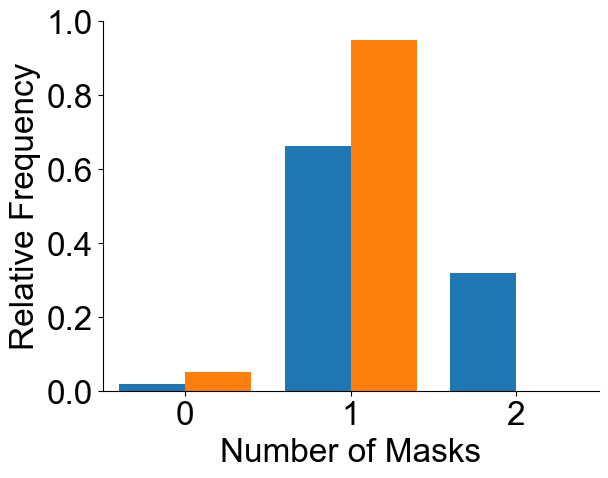

In [27]:
import matplotlib.font_manager as fm

# Path to your downloaded arial.ttf file
font_path = '/pscratch/sd/k/kerrilu/arial.ttf'
fe = fm.FontEntry(fname=font_path, name='Arial')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams['font.family'] = fe.name
plt.rcParams["font.sans-serif"] = "Arial"

plt.rc('font', size=24)          
plt.rc('axes', titlesize=24)     
plt.rc('axes', labelsize=24)    
plt.rc('xtick', labelsize=24)    
plt.rc('ytick', labelsize=24)    
plt.rc('figure', titlesize=24)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

width = 0.4
plt.bar(results_table_test['Final Mask Number'].value_counts().index - width/2, results_table_test['Final Mask Number'].value_counts().values/len(results_table_test), width, label='asymptotic')
plt.bar(results_table_test_finite_sample['Final Mask Number'].value_counts().index + width/2, results_table_test_finite_sample['Final Mask Number'].value_counts().values/len(results_table_test_finite_sample), width, label='finite sample')
plt.xticks(np.arange(0, 3))
plt.xlim([-0.5, 2.5])
plt.ylim([0, 1])
plt.xlabel("Number of Masks")
plt.ylabel("Relative Frequency")
#plt.legend()
plt.show()